In [ ]:
import pandas as pd
import json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [64]:
def extract_all_records(filepath: str) -> list:
    """Extrai métricas relevantes de um JSON F-UJI que contém múltiplos objetos."""
    with open(filepath, encoding="utf-8") as f:
        data = json.load(f)
 
    # Se o JSON for uma lista direta [ {}, {}, {} ], usamos ela.
    items_to_process = data if isinstance(data, list) else [data]

    all_records = []

    for item in items_to_process:
        record = {
            "arquivo": Path(filepath).name,
            "uid": item.get("request", {}).get("object_identifier", ""),
            "repositorio": "",
            "timestamp": item.get("start_timestamp", ""),
            "score_total": item.get("summary", {}).get("score_earned", {}).get("FAIR", 0),
        }
     
        # Infere repositório a partir do UID (subdomínio antes do .br)
        uid = record["uid"]
        if "handle" in uid:
            # Isola o domínio (ex: "ri.ufrb.edu.br")
            domain = uid.replace("https://", "").replace("http://", "").split("/")[0]
            
            if ".br" in domain:
                # Remove o .br e divide pelos pontos -> ['ri', 'ufrb', 'edu']
                parts = domain.split(".br")[0].split(".")
                
                if parts:
                    # Se o último elemento for um sufixo comum, pega o penúltimo
                    if parts[-1] in ("edu", "gov", "com", "org"):
                        # Garante que existe um penúltimo elemento antes de acessar
                        record["repositorio"] = parts[-2] if len(parts) > 1 else parts[-1]
                    else:
                        # Caso contrário (ex: "pantheon.ufrj.br" -> ['pantheon', 'ufrj']), pega o último
                        record["repositorio"] = parts[-1]
     
        # Extrai os scores detalhados do sumário (F1, A1.1, etc.)
        score_earned_dict = item.get("summary", {}).get("score_earned", {})
        for principle, score in score_earned_dict.items():
            if principle != "FAIR":
                # Troquei o ponto por underline para evitar problemas em exportações (ex: score_A1_1)
                p_clean = principle.replace(".", "_")
                record[f"score_{p_clean}"] = score

        # Adiciona o registro atual na lista de resultados
        all_records.append(record)
 
    return all_records

In [65]:
caminho_da_pasta = Path("data")

lista_mestra_registros = []

# Procura por todos os arquivos que terminam com .json na pasta
for arquivo_path in caminho_da_pasta.glob("*.json"):
    print(f"Processando arquivo: {arquivo_path.name}")
    
    registros_do_arquivo = extract_all_records(str(arquivo_path))
    
    lista_mestra_registros.extend(registros_do_arquivo)

df_final = pd.DataFrame(lista_mestra_registros)

# Visualizar o resultado
print(f"\nProcessamento concluído! Total de linhas na base: {len(df_final)}")

Processando arquivo: ri.ufrb.edu.br2.txt_output.json
Processando arquivo: repositorio.ufms.br2.txt_output.json
Processando arquivo: pantheon.ufrj.br3.txt_output.json
Processando arquivo: app.uff.br-riuff2.txt_output.json
Processando arquivo: repositorio.ufra.edu.br-jspui2.txt_output.json
Processando arquivo: repositorio.ufu.br2.txt_output.json
Processando arquivo: repositorio.ufsm.br2.txt_output.json
Processando arquivo: repositorio.uft.edu.br2.txt_output.json
Processando arquivo: repositorio.unifesspa.edu.br2.txt_output.json
Processando arquivo: acervodigital.ufpr.br-xmlui2.txt_output.json
Processando arquivo: www.repositorio.ufal.br2.txt_output.json
Processando arquivo: repositorio.utfpr.edu.br-jspui2.txt_output.json
Processando arquivo: ri.ufmt.br2.txt_output.json
Processando arquivo: bdtd.uftm.edu.br2.txt_output.json
Processando arquivo: repositorio.ufpe.br2.txt_output.json

Processamento concluído! Total de linhas na base: 1406


In [80]:
print(type(df_final))
df_final['repositorio'] = df_final['repositorio'].str.upper()

<class 'pandas.DataFrame'>


In [84]:
itens_per_repositorio = df_final.groupby("repositorio").size().reset_index(name="quantidade")
print(itens_per_repositorio)

   repositorio  quantidade
0         UFAL         100
1          UFF         100
2         UFMS         100
3         UFMT         100
4         UFPE         100
5         UFPR         100
6         UFRA           6
7         UFRB         100
8         UFRJ         100
9         UFSM         100
10         UFT         100
11        UFTM         100
12         UFU         100
13   UNIFESSPA         100
14       UTFPR         100


In [81]:
cols = ['score_total','score_A',
       'score_F', 'score_I', 'score_R', 'score_A1', 'score_A1_1', 'score_A1_2',
       'score_F1', 'score_F2', 'score_F3', 'score_F4', 'score_I1', 'score_I2',
       'score_I3', 'score_R1', 'score_R1_1', 'score_R1_2', 'score_R1_3']

df_grouped = df_final[['repositorio'] + cols].groupby('repositorio').agg(['mean', 'std'])
df_estatisticas = df_grouped.stack(level=0).reset_index()
print(df_estatisticas)


    repositorio      level_1   mean       std
0          UFAL  score_total  12.04  0.400000
1          UFAL      score_A   4.00  0.000000
2          UFAL      score_F   4.98  0.200000
3          UFAL      score_I   0.06  0.342893
4          UFAL      score_R   3.00  0.000000
..          ...          ...    ...       ...
280       UTFPR     score_I3   0.02  0.200000
281       UTFPR     score_R1   1.00  0.000000
282       UTFPR   score_R1_1   0.00  0.000000
283       UTFPR   score_R1_2   1.00  0.000000
284       UTFPR   score_R1_3   1.00  0.000000

[285 rows x 4 columns]


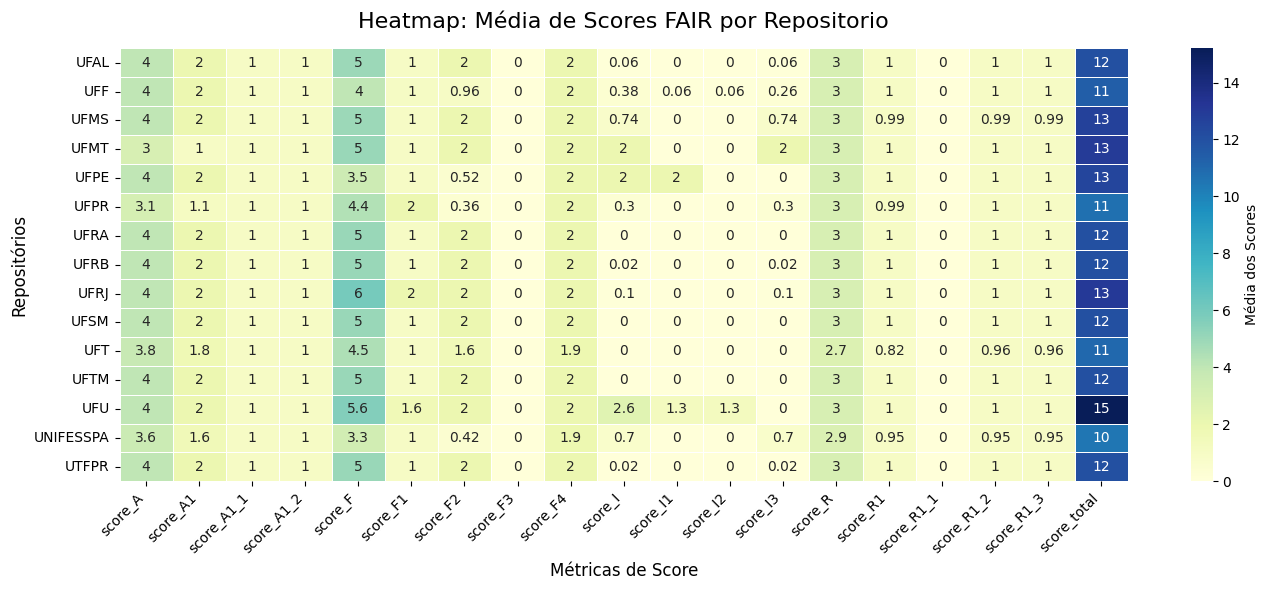

In [ ]:
df_heatmap = df_estatisticas.pivot(
    index="repositorio", columns="level_1", values="mean"
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    df_heatmap,
    annot=True,  
    cmap="YlGnBu",  
    linewidths=0.5,  
    cbar_kws={"label": "Média dos Scores"},  # Legenda da barra de cores
)

plt.title("Heatmap: Média de Scores FAIR por Repositorio", fontsize=16, pad=15)
plt.xlabel("Métricas de Score", fontsize=12)
plt.ylabel("Repositórios", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

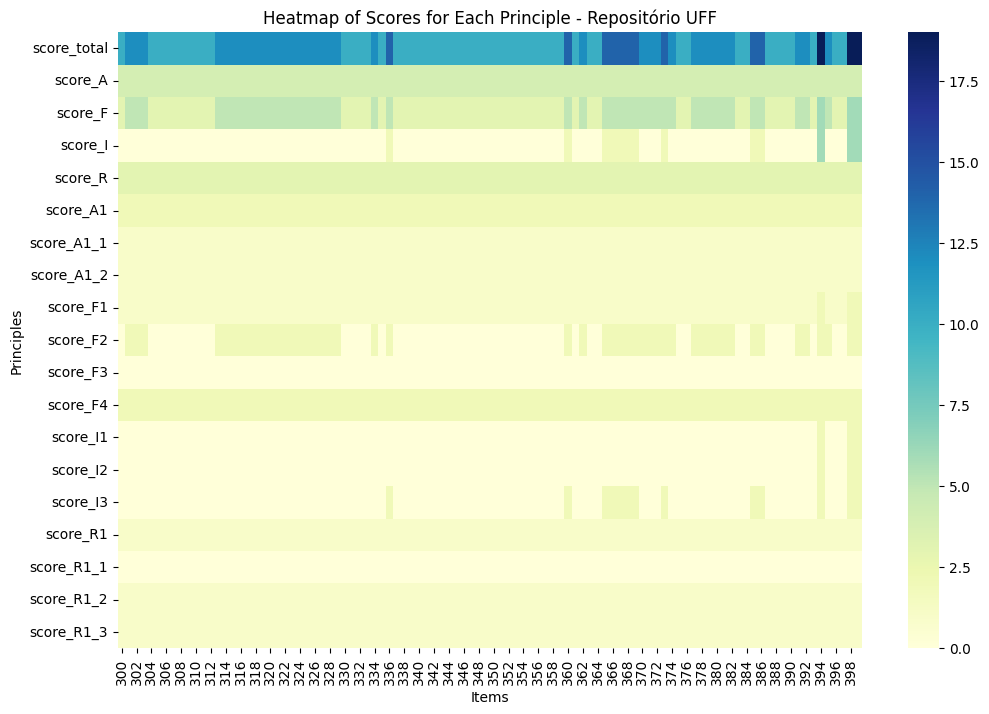

In [ ]:
df = df_final[df_final['repositorio'] == 'uff']

score_columns = [col for col in df.columns if col.startswith("score_")]
score_data = df[score_columns]

plt.figure(figsize=(12, 8))
sns.heatmap(score_data.T, cmap="YlGnBu")
plt.title("Heatmap of Scores for Each Principle - Repositório UFF")
plt.xlabel("Items")
plt.ylabel("Principles")
plt.show()